Final Project

In [25]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer , ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation


In [26]:
df = pd.read_csv('hotel_final.csv')
# lets drop the unnamed column 
df = df.drop(columns = ['Unnamed: 0'])
df.head()

,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,-ZkzDLAp-6LSdek-nU,"My husband took me to stay the night for a fun date night one year and I'm finally getting around to writing a review of this place. Well, it's the W hotel, which obviously means it's stylish, cool, trendy, all in once place with an exceptional location in Chi-town overlooking Lake Michigan. We were there in the winter so I can't speak for spending time outside the hotel facilities so we definitely took full advantage of the inside. The people at the lobby were super nice, the decor was fab-u-lous throughout and the actual hotel room was spacious, clean and had a very chic feel to it. We left as happy guests. The best part of the hotel is that it houses Wave restaurant which is like Mediterranean tapas and it's absolutely delicious and definitely cost effective. This 4 star hotel is a great location to stay for both tourists, locals and even if you're on business trips, the concierge will be friendly and polite and the bar is definitely worth checking out and if time allows, make a reservation at Wave. And I have to mention that I got a really good night's sleep when we stayed our one night, bed was super comfy and those pillows, I was seriously contemplating taking them home with me.",4,0,0,0
1,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a fantastic rate on priceline. We took the blue line to Clark/Lake and then took the taxi to the hotel. Check in process was smooth, we had a wonderful room with a view of buildings across the street. Room was nicely furnished, flat screen, high beds, window shades between bedroom and bathroom. The room smelled nice and the furnishings were in a fine condition. We got a glimpse of the rooms with a view from the elevator waiting area - it looks our directly at a beautiful beach with Navy Pier to the right. I can imagine how amazing it must be to wake up with that view in the morning. It was raining on Friday night, we asked to use the hotel umbrella when we went out for dinner but apparently they were all out. The agent at the front desk offered us her personally umbrella but we declined (I think her name was Arianna - great service). We also had forgotten the charger for our iPhones, although they weren't able to send us one for our room, it was no problem to stop by the front desk and leave it there to charge in the back. We did that for 2 nights. The welcome desk was a little chaotic the two times we needed to speak to them, and when we did their attitude wasn't entirely pleasant. That was the only minor flaw to the hotel besides the unusually slow elevators that seemed to stop at every floor every time we needed to go to the lobby. We had plans all weekend, so didn't get to use the pool, restaurants or bars on site. We rented a zip car for 2 hours for our little excursion on Hot Doug's on Saturday morning. The car was parked a block away in a lot, very convenient. Other times we took the Red line (Chicago), explored the city on foot, and at the end of the night we took the taxi to the hotel. The W Lakeshore is located a bit far from the river and Michigan Ave. but the lake view is simply breath taking. If the weather was warmer, the pedestrian path by the lake and the beach is just across the street. Perfect for someone who wants to go for a jog or just relax by the water.",3,0,0,0
2,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of the W concept. This hotel has both good and bad. The rooms are very updated and comfortable, but- the soundproofing stinks. Had to swicth rooms and still was awakended by noise the next morning. The staff is very friendly, but- they are so friendly it takes them forever to check you in, so the folks behind you get to wait. The location next to the lake is great, especially if you have a lakeview, but- it's also far from everything else, with few amenities in immediate walking distance. Probably will hit up the Westin on my next stay. 

## perform simple exploratory data analysis 


In [27]:
# missing value analysis
df.isnull().sum()

reviewID         0
reviewContent    0
rating           0
usefulCount      0
coolCount        0
funnyCount       0
dtype: int64

---

<Axes: xlabel='rating'>

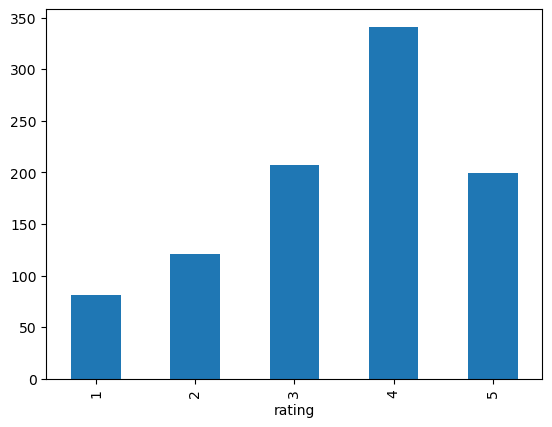

In [28]:
rating_counts = df['rating'].value_counts().sort_index()
rating_counts.plot(kind= 'bar')

there is a slight skew towards 4 and 5 

### need to create sentiment groups, happy, unhappy , neutral

In [29]:
text_train = df['reviewContent']

steps: 
- instantiate vectorizer with parameters: vec 
- vectorize column of text with fit_transfor : X 
- Instantiate LDA model with parameters : lda
- fit LDA model to vectorized text: doc_topics

add some more custom stop words 
- https://pmc.ncbi.nlm.nih.gov/articles/PMC9672446/ (Irrelevant words removal: In addition to eliminating common stop words, eliminating irrelevant terms is a beneficial task in the pre-processing process, which involves eliminating noisy terms such as names of attractions, links, and proper nouns.)
- https://dasunpubudumal.medium.com/record-matching-for-hotel-data-20773742bc31


prompted claude , "given the sources above can you help me create a list of domain specific stop words I can include in addition to the standard english stop words"

In [30]:
domain_stops = [
    'hotel', 'hotels', 'room', 'rooms', 'stay', 'stayed', 'staying',
    'night', 'nights', 'chicago', 'vegas',
    'just', 'like', 'got', 'really', 'definitely', 'place', 'time',
    'went', 'did', 'didn', 've', 'don', 'll',
    'said', 'told', 'know', 'think', 'pretty', 'good', 'great', 'nice',
    'little', 'bit', 'lot', 'people', 'things', 'thing', 'way', 'sure',
    'want', 'wanted', 'make', 'made', 'look', 'looked', 'looks', 'feel',
    'felt', 'guess', 'overall', 'couple', 'maybe', 'actually'
]
custom_stops = list(ENGLISH_STOP_WORDS) + domain_stops
print(f"Total stopwords in filter: {len(custom_stops)}")

Total stopwords in filter: 372


In [31]:
vec = CountVectorizer(stop_words=custom_stops)
X = vec.fit_transform(text_train)
lda = LatentDirichletAllocation(n_components=2)
doc_topics = lda.fit_transform(X)
print(f"There are {lda.components_.shape[0]} topics and {lda.components_.shape[1]} words")

There are 2 topics and 8164 words


Extract top words from each topic

In [32]:
voc = np.array(vec.get_feature_names_out())

In [33]:
# set number of top words you want 
n_words = 5 
# create lambda function to extra top words from voc 

imp_words = lambda x : [voc[each] for each in np.argsort(x)[:-n_words-1:-1]]

In [34]:
# use imp_words to extract words with the highest weights from our lda model 
words_in_topic = ([imp_words(x) for x in lda.components_])
# examine words 
words_in_topic

[['service', 'lobby', 'view', 'location', 'bar'],
 ['lobby', 'bed', 'staff', 'check', 'location']]

In [35]:
# join words into a single string 
main_topics = [' '.join(x) for x in words_in_topic]
# create dataframe with top words and set index to topic number 
main_topics_df = pd.DataFrame( {"top_words" : main_topics} , index = ["Topic_" + str(each) for each in range(lda.n_components)])
# Examine the top words
main_topics_df

,top_words
Topic_0,service lobby view location bar
Topic_1,lobby bed staff check location


# Create a Document topic matrix from results

In [36]:
# Our input weight vector is doc_topics 
# this is a 2d array that is the proportion of the words in each document generated from that topic 

doc_topics

array([[0.98963098, 0.01036902],
       [0.99375502, 0.00624498],
       [0.98043885, 0.01956115],
       ...,
       [0.52050737, 0.47949263],
       [0.95914264, 0.04085736],
       [0.9697869 , 0.0302131 ]])

In [37]:
# Set cols and docs to use to create a dataframe below 
cols = ['Topic_' + str(each) for each in range(lda.n_components)]
docs = ['Document_' + str(each) for each in range(X.shape[0])]

In [38]:
# create dataframe with documents proportions in each topic 
df_topics = pd.DataFrame(np.round(doc_topics , 2) , columns = cols , index = docs)
# Examine documents and topic proportions (document-topic matrix)
df_topics

,Topic_0,Topic_1
Document_0,0.99,0.01
Document_1,0.99,0.01
Document_2,0.98,0.02
Document_3,0.99,0.01
Document_4,0.34,0.66
...,...,...
Document_944,0.29,0.71
Document_945,0.94,0.06
Document_946,0.52,0.48
Document_947,0.96,0.04


In [39]:
# Classify each document as topic 0 or topic 1 based on proportion 
imp_topic = np.argmax(df_topics.values, axis =1)
# Create new column called top_topic with 0 or 1 based on classification results
df_topics['top_topic'] = imp_topic
df_topics

,Topic_0,Topic_1,top_topic
Document_0,0.99,0.01,0
Document_1,0.99,0.01,0
Document_2,0.98,0.02,0
Document_3,0.99,0.01,0
Document_4,0.34,0.66,1
...,...,...,...
Document_944,0.29,0.71,1
Document_945,0.94,0.06,0
Document_946,0.52,0.48,0
Document_947,0.96,0.04,0


In [40]:
# Assign name based on domain 

df_topics['topic_name'] = np.where(df_topics['top_topic'] ==1 , 'bruh_what' , '????')
# Compare our topic model results with the original raw text 
pd.set_option('display.max_colwidth' , None) # This lets us see whole text of reviews columns 
pd.concat([df_topics.reset_index() , text_train], axis =1)
## how dominant is the topic in each document 
# fundamentally: the proportion of the words in each document generated from that topic 
df_topics


,Topic_0,Topic_1,top_topic,topic_name
Document_0,0.99,0.01,0,????
Document_1,0.99,0.01,0,????
Document_2,0.98,0.02,0,????
Document_3,0.99,0.01,0,????
Document_4,0.34,0.66,1,bruh_what
...,...,...,...,...
Document_944,0.29,0.71,1,bruh_what
Document_945,0.94,0.06,0,????
Document_946,0.52,0.48,0,????
Document_947,0.96,0.04,0,????


---

Lets have an additional approach (using hugging face models)

In [41]:
#!pip install bertopic sentence-transformers

In [42]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

https://huggingface.co/BAAI/bge-base-en-v1.5

In [44]:
# --- 1. Define custom stopwords (in case kernel was restarted) ---
domain_stops = [
    'hotel', 'hotels', 'room', 'rooms', 'stay', 'stayed', 'staying',
    'night', 'nights', 'chicago', 'vegas',
    'just', 'like', 'got', 'really', 'definitely', 'place', 'time',
    'went', 'did', 'didn', 've', 'don', 'll',
    'said', 'told', 'know', 'think', 'pretty', 'good', 'great', 'nice',
    'little', 'bit', 'lot', 'people', 'things', 'thing', 'way', 'sure',
    'want', 'wanted', 'make', 'made', 'look', 'looked', 'looks', 'feel',
    'felt', 'guess', 'overall', 'couple', 'maybe', 'actually'
]
custom_stops = list(ENGLISH_STOP_WORDS) + domain_stops

# --- 2. Prepare documents ---
docs = df['reviewContent'].tolist()

# --- 3. Embedding model (Hugging Face sentence transformer) ---
embedding_model = SentenceTransformer('BAAI/bge-base-en-v1.5')

# --- 4. Vectorizer model (controls the topic LABELS, filters stopwords) ---
vectorizer_model = CountVectorizer(
    stop_words=custom_stops,
    min_df=5,
    ngram_range=(1, 2)      # keep unigrams AND bigrams ("front desk", "customer service")
)

# --- 5. BERTopic model ---
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=15,
    nr_topics='auto',
    calculate_probabilities=True,
    verbose=True
)

# --- 6. Fit ---
topics, probs = topic_model.fit_transform(docs)

# --- 7. Inspect results ---
topic_info = topic_model.get_topic_info()
print(f"\nBERTopic discovered {len(topic_info) - 1} topics (excluding outliers)\n")

for topic_id in topic_info['Topic']:
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f"Topic {topic_id} (n={count}): {', '.join(words)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-20 23:04:32,698 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

2026-04-20 23:05:49,532 - BERTopic - Embedding - Completed ✓
2026-04-20 23:05:49,533 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-20 23:05:50,838 - BERTopic - Dimensionality - Completed ✓
2026-04-20 23:05:50,839 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-20 23:05:50,870 - BERTopic - Cluster - Completed ✓
2026-04-20 23:05:50,871 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-20 23:05:50,980 - BERTopic - Representation - Completed ✓
2026-04-20 23:05:50,981 - BERTopic - Topic reduction - Reducing number of topics
2026-04-20 23:05:50,988 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 23:05:51,105 - BERTopic - Representation - Completed ✓
2026-04-20 23:05:51,107 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5



BERTopic discovered 4 topics (excluding outliers)

Topic 0 (n=322): location, view, bar, service, lobby, staff, check, beautiful, clean, big
Topic 1 (n=314): service, bed, desk, lobby, door, bathroom, staff, small, day, location
Topic 2 (n=86): house, lobby, wedding, old, beautiful, floor, location, love, small, right
Topic 3 (n=71): lake, lakeshore, view, spa, bar, bathroom, staff, pier, service, floor
